# 🌤 Hava Durumu Sıcaklığı

🔥 Bu, Python ve RNN bilginizi gerçekten test edecek uzun bir challenge'dır. 

🧑🏻‍🎓 Her şeyi dikkatli bir şekilde okuyun. 

💻 Kodlama bölümleri `laptop` emoji'si ile gösterilmiştir.

⏳ Bugün bitiremezseniz, bootcamp sonrasında geri dönmeye kesinlikle değer bir challenge'dır.

### Kütüphaneler

1. Olağan kütüphaneleri içe aktaralım:

In [ ]:
# Data manipulation
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)

# Data Visualiation
import matplotlib.pyplot as plt
import seaborn as sns

# System
import os

# Deep Learning
import tensorflow as tf


2. Zamansal veri manipülasyonu zordur, Python fonksiyonlarımızda kullanacağımız değişken türlerini kontrol etmek için 📚 [`typing`](https://docs.python.org/3/library/typing.html) kütüphanesini de içe aktaralım:

In [ ]:
from typing import Dict, List, Tuple, Sequence


# (0) Hava durumu sıcaklık challenge'ı

## (0.0) Giriş

🧑🏻‍🏫 **Hedefler:**
- Bir Tekrarlayan Sinir Ağına beslenecek bir veri setini hazırlamak
- Zaman Serileri hakkında daha iyi bir anlayış geliştirmek

❗️ **Uyarı/Sorumluluk Reddi**:
- Bu challenge gerçekten **zamansal verilerle nasıl başa çıkılacağını** anlamak için tasarlanmıştır, LSTM'nin farklı kapılarına veya "en iyi" tekrarlayan ağı tasarlamasına odaklanmak yerine LSTM mimarisini bir _araç_ olarak kullanır.

🎯 **ML hedefi**:
* Bu challenge'da, **gelecek 3, 6, 9, 12... saatteki sıcaklığı tahmin etmek** istiyoruz... 
* ...geçmiş sıcaklık, atmosferik basınç, nem vb. gibi hava durumu özellikleri dizisine dayanarak.

## (0.1) Hava durumu veri seti

### (0.1.1) Veri setinin yüklenmesi

🌤 Bu challenge, [**Max-Planck Biyojeokimya Enstitüsü**](https://www.bgc-jena.mpg.de/index.php/Main/HomePage) tarafından kaydedilen bir [**hava durumu zaman serileri veri setini**](https://www.bgc-jena.mpg.de/wetter/) kullanır. Bu veri seti, 2003'ten başlayarak her 10 dakikada bir toplanan _hava sıcaklığı_, _atmosferik basınç_ ve _nem_ gibi $14$ farklı özellik içerir (~ 420k satır). Ancak verimlilik için, 2009 ile 2016 arasında her üç saatte bir toplanan verileri "sadece" kullanacaksınız. Gerçekten de, bu zaman aralığı belirli bir gün boyunca sıcaklığın evrimini gözlemlemek için makul görünüyor.

🛠 Sizin için aşağıdaki özellik mühendisliği adımlarını zaten gerçekleştirdik:
- her üç saatte bir tahminlere odaklanmak için her $18$'inci kaydı almak $ ( 18 =  \frac{6 kayıt}{saat} \times 3 saat)$
- safsız değerleri değiştirmek
- _rüzgar_: rüzgar yönlerini (`Wx`, `Wy`) koordinatlarına sahip rüzgar vektörleri olarak hesaplamak
- (`Day sin`, `Day cos`) ve (`Year sin`, `Year cos`) aracılığıyla saklanan _günlük ve yıllık periyodiklikleri_ hesaplamak

👇 Bize güvenin ve bu challenge için zaten ön işlemden geçirilmiş bu veri setinden başlayın 👇

In [ ]:
url = "https://d37p7d5kaxknzw.cloudfront.net/projects/weather_every_three_hours.csv"
df = pd.read_csv(url).drop(columns = ['Unnamed: 0'])
df


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day_sin,Day_cos,Year_sin,Year_cos
0,996.84,-8.81,264.59,-9.66,93.50,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,7.071068e-01,7.071068e-01,0.011483,0.999934
1,997.71,-9.67,263.66,-10.62,92.70,2.93,2.71,0.21,1.69,2.72,1317.71,-0.041452,0.027960,-0.414519,0.279596,1.000000e+00,4.339955e-12,0.013633,0.999907
2,999.69,-7.66,265.52,-8.84,91.20,3.43,3.13,0.30,1.95,3.13,1310.14,-0.314796,-0.128466,-0.583298,-0.238040,7.071068e-01,-7.071068e-01,0.015783,0.999875
3,1000.30,-6.87,266.27,-8.28,89.60,3.64,3.27,0.38,2.03,3.26,1306.98,-1.834577,-0.141163,-2.622249,-0.201771,6.903299e-12,-1.000000e+00,0.017933,0.999839
4,999.88,-5.69,267.48,-7.00,90.40,3.99,3.61,0.38,2.25,3.61,1300.51,-0.825870,0.828758,-1.327039,1.331679,-7.071068e-01,-7.071068e-01,0.020083,0.999798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23358,1006.23,-6.31,266.37,-8.42,84.90,3.81,3.23,0.57,2.00,3.21,1312.01,-1.279930,-0.013404,-1.839899,-0.019268,6.755902e-01,-7.372773e-01,-0.000268,1.000000
23359,1004.62,-0.71,272.09,-5.97,67.37,5.80,3.91,1.89,2.42,3.89,1282.65,-0.976457,-0.412471,-1.916066,-0.809378,-4.361939e-02,-9.990482e-01,0.001883,0.999998
23360,1003.09,4.97,277.88,-3.04,56.03,8.71,4.88,3.83,3.03,4.86,1254.09,-0.403185,-0.359224,-0.776504,-0.691840,-7.372773e-01,-6.755902e-01,0.004033,0.999992
23361,1002.27,-0.42,272.56,-4.92,71.50,5.92,4.23,1.69,2.63,4.22,1278.14,-0.266024,-0.350473,-0.604599,-0.796530,-9.990482e-01,4.361939e-02,0.006183,0.999981


👆 Ön işlemden geçirilmiş veri setinde şunlar var:
- $23$k satır  (~ 8 yıllık hava durumu verisi)
- $19$ özellik şu şekilde oluşmuş:
    - $1$ <font color=green>**hedef**</font> (sıcaklığın geçmiş değerlerini bir özellik olarak kullanacağız)
    - $18$ <font color=orange>**geçmiş kovaryatlar**</font> (= geçmiş değerleri bilinen özellikler)
    - $0$ <font color=blue>**gelecek kovaryatlar**</font> (= gelecek değerleri bilinen özellikler, örn. resmi tatiller)

    
<img src='https://github.com/lewagon/data-images/blob/master/DL/time-series-covariates.png?raw=true' width=800>

👨🏻‍🏫 Bu hava durumu veri seti, 2009'un başından 2016'nın sonuna kadar her 3 saatte bir kayda sahip tek bir Zaman Serisi olan bir DataFrame'dir (boyut = 2).

* `df.shape = (n_timesteps, n_features) = (23363, 19)`

<details>
    <summary>Toplamda 8 yıllık verimiz var</summary>

$ \frac{23363 kayıt}{365 \frac{gün}{yıl} \times 24 \frac{saat}{gün} \times \frac{1 kayıt}{3 saat}} = \frac{23363 kayıt}{2920 \frac{kayıt}{yıl}} = 8 yıl = (2016 - 2009 + 1 ) yıl$
    
</details>

🎯 Hedef, geçmiş değerleri kullanarak 3, 6, 9, 12, ... saat sonraki sıcaklığı tahmin etmektir.

In [ ]:
# Let's define the global variables of our dataset
TARGET = 'T (degC)'
N_TARGETS = 1
N_FEATURES = 19


### (0.0.2) Zaman Serinizi Görselleştirme

📈  İşte bazı özelliklerin ***zaman içindeki evrimi***:
* `T (degC)` (sıcaklık)
* `p (mbar)` (atmosferik basınç)
* `rho (g/m**3)` (atmosferik yoğunluk)



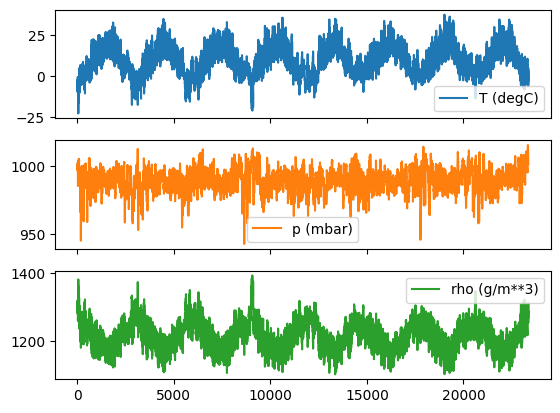

In [ ]:
plot_cols = [TARGET, 'p (mbar)', 'rho (g/m**3)']
plot_features = df[plot_cols]
plot_features.index = df.index
plot_features.plot(subplots = True);


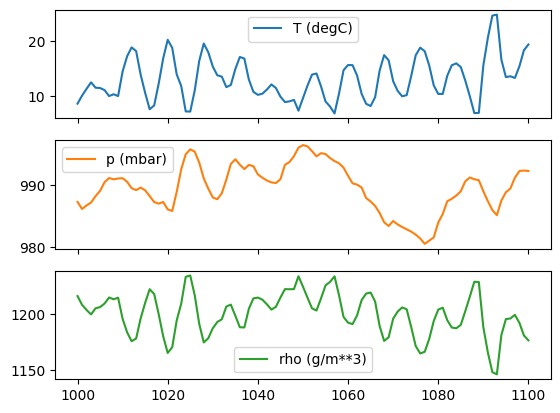

In [ ]:
zoomed_slice = slice(1000,1100)

plot_features = df.loc[zoomed_slice, plot_cols]
plot_features.plot(subplots = True);


# (1) Veri setini hazırlayın

##  (1.0) Büyük resim

<b><u>Adım 1: Zaman Serilerinde Çapraz Doğrulama [FOLDS] </u></b>

* Bu tek Zaman Serisinden başlayarak, <font color="#c91ac9">**FOLDS**</font> oluşturacağız...
* ... ve sinir ağının sağlamlığı hakkında sonuç çıkarmak için LSTM'imizi bu farklı <font color="#c91ac9">**FOLDS**</font> üzerinde eğitip değerlendireceğiz
* Tüm dış koşul türlerini kapsayacak şekilde Zaman Serisi tahminlemede ***yüzlerce*** <font color="#c91ac9">**FOLD**</font> oluşturmak çok yaygındır: örn.
    - çöküş piyasa dönemleri 📉
    - boyl piyasalar 📈
    - durgun piyasalar 😴, vb...

<b><u>Adım 2: Her katman içinde Holdout yöntemi [TRAİN-TEST SPLIT]</u></b>

* Her <font color="#c91ac9">**FOLD**</font> için, bir TRAIN-TEST SPLIT yapacağız:
    * Modeli <font color=blue>**train**</font> seti üzerinde <font color=blue>**fit**</font> etmek 
    * ve <font color="#ff8005">**test**</font> seti üzerinde <font color="#ff8005">**değerlendirmek**</font>
    * Train setini her zaman test setinden **kronolojik olarak** önce bölün!

👇 İlk iki adım, 4 FOLD içeren aşağıdaki görüntüde özetlenebilir:

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/time_series_cross_validation.png" alt="Time Series Cross Validation" width="800">

<b><u>Adım 3: Hem train setinde hem de test setinde SEQUENCES örneklemesi</u></b>

Her <font color=blue>**train**</font> setinde ve her <font color="#ff8005">**test**</font> setinde, aşağıda gösterildiği gibi <font color=magenta>**rastgele diziler**</font> oluşturacağız 👇:

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/big_picture_temporal_data_handling.png" alt="Sequences in each fold" width="500"> 



## (1.1) 💻 Çapraz doğrulama için <font color="#c91ac9">**FOLD**</font> oluşturma

Her biri `(FOLD_LENGTH, n_features)` şekline sahip 

🌐 Bu notebook'ta testlerimizde her yerde kullanacağımız bazı global değişkenleri tanımlayalım:

In [ ]:
# --------------------------------------------------- #
# Let's consider FOLDS with a length of 3 years       #
# (2 years will be used for train, 1 for test!)       #
# --------------------------------------------------- #

FOLD_LENGTH = 8*365 * 3 # every 3 hrs x 8 = 24h
                        # three years

# --------------------------------------------------- #
# Let's consider FOLDS starting every trimester       #
# --------------------------------------------------- #

FOLD_STRIDE = 8*91 # every 3 hrs x 8 = 24h
                   # 1 quarter = 91 days

# --------------------------------------------------- #
# Let's consider a train-test-split ratio of 2/3      #
# --------------------------------------------------- #

TRAIN_TEST_RATIO = 0.66


💻 ❓ **Soru (<font color="#c91ac9">FOLD</font>lar)** ❓

Aşağıda fold'ları oluşturmak için kullanacağımız `get_folds` fonksiyonunu kodlayın  `folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)`

In [ ]:
def get_folds(
    df: pd.DataFrame,
    fold_length: int,
    fold_stride: int) -> List[pd.DataFrame]:
    """
    This function slides through the Time Series dataframe of shape (n_timesteps, n_features) to create folds
    - of equal `fold_length`
    - using `fold_stride` between each fold

    Args:
        df (pd.DataFrame): Overall dataframe
        fold_length (int): How long each fold should be in rows
        fold_stride (int): How many timesteps to move forward between taking each fold

    Returns:
        List[pd.DataFrame]: A list where each fold is a dataframe within
    """
    # $CHALLENGIFY_BEGIN

    folds = []
    for idx in range(0, len(df), fold_stride):
        # Exits the loop as soon as the last fold index would exceed the last index
        if (idx + fold_length) > len(df):
            break
        fold = df.iloc[idx:idx + fold_length, :]
        folds.append(fold)
    return folds

    # $CHALLENGIFY_END


🧪 ***Kodunuzu test edin***

In [ ]:
folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)

print(f'The function generated {len(folds)} folds.')
print(f'Each fold has a shape equal to {folds[0].shape}.')


The function generated 21 folds.
Each fold has a shape equal to (8760, 19).


In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('folds',
                         number_of_folds = len(folds),
                         fold_shape = folds[0].shape)
result.write()
print(result.check())


☝️ Bu <font color="#c91ac9">**FOLD**</font> sayısı modelimizi doğru şekilde çapraz doğrulamak için yeterli olmalıdır !

## (1.2) 💻 Zamansal <font color=blue>**Eğitim**</font>/<font color="#ff8005">**Test**</font> Ayrımı

👩🏻‍🏫 Şimdilik bir fold'a odaklanalım.

In [ ]:
fold = folds[0]
fold


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day_sin,Day_cos,Year_sin,Year_cos
0,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,7.071068e-01,7.071068e-01,0.011483,0.999934
1,997.71,-9.67,263.66,-10.62,92.7,2.93,2.71,0.21,1.69,2.72,1317.71,-0.041452,0.027960,-0.414519,0.279596,1.000000e+00,4.339955e-12,0.013633,0.999907
2,999.69,-7.66,265.52,-8.84,91.2,3.43,3.13,0.30,1.95,3.13,1310.14,-0.314796,-0.128466,-0.583298,-0.238040,7.071068e-01,-7.071068e-01,0.015783,0.999875
3,1000.30,-6.87,266.27,-8.28,89.6,3.64,3.27,0.38,2.03,3.26,1306.98,-1.834577,-0.141163,-2.622249,-0.201771,6.903299e-12,-1.000000e+00,0.017933,0.999839
4,999.88,-5.69,267.48,-7.00,90.4,3.99,3.61,0.38,2.25,3.61,1300.51,-0.825870,0.828758,-1.327039,1.331679,-7.071068e-01,-7.071068e-01,0.020083,0.999798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,980.34,1.45,276.18,0.03,90.2,6.79,6.12,0.67,3.89,6.24,1240.67,-0.604351,-3.731375,-1.191115,-7.354165,-8.715574e-02,-9.961947e-01,-0.028744,0.999587
8756,983.25,2.23,276.73,0.21,86.4,7.18,6.20,0.98,3.93,6.31,1240.81,-0.432628,-2.126437,-0.849307,-4.174479,-7.660444e-01,-6.427876e-01,-0.026594,0.999646
8757,985.46,1.69,276.00,-0.52,85.2,6.90,5.88,1.02,3.72,5.97,1246.23,-0.626578,-2.513066,-0.977364,-3.919995,-9.961947e-01,8.715574e-02,-0.024445,0.999701
8758,986.63,2.16,276.38,-1.14,78.7,7.14,5.62,1.52,3.55,5.70,1245.68,-0.773266,-3.669409,-1.222791,-5.802558,-6.427876e-01,7.660444e-01,-0.022295,0.999751


☝️ Bu fold'u **kronolojik olarak** şu şekilde bölmek istiyoruz:

- bir <font color=blue>fold_train</font> dataframe'i
- bir <font color="#ff8005">fold_test</font> dataframe'i

Bu dataframe'ler, bir sonraki adımda her dataframe'de birçok `(X_i, y_i)` çifti örneklemek için ihtiyaç duyduğumuz tüm veriyi içerecek! 

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/time_serie_test_split_without_horizon.png" alt="train_test_split_temporal" width="800"> 


☝️ Fark ettiniz mi? 

- <font color="#ff8005">y_test_first</font> <font color=blue>y_train_last</font>'tan hemen sonra olmalıdır
  
- <font color="#ff8005">fold_test</font>'imizde hangi indekslerin olması gerektiğini bilmek için, her `X_i` gözleminin `INPUT_LENGTH`'ini bilmemiz gerekir 
  
- `INPUT_LENGTH` büyük olabileceğinden, eğitim ve test fold'ları arasında bazı çakışmaların olması tamamen normaldir! (1 yıllık input_length aldığınızı düşünün, eğitim ve test arasında bir yıl beklemezdiniz!)


**❓ Anlama Sorusu**: <font color=blue>fold_train</font> zaman adımı indekslerinin `[0..len_train]` aralığında olduğu göz önüne alındığında, <font color="#ff8005">fold_test</font> indeks aralığı ne olmalıdır?

<details>
  <summary markdown='span'>💡 Cevap</summary>

Eğer `fold_train` indeksleri `[0:len_train]` ise, o zaman `fold_test` indeksleri `[len_train-INPUT_LENGTH, :]` olacaktır
</details>



✅ O halde, problemimiz için 2 haftaya eşit bir `INPUT_LENGTH` ayarlayalım (bu, hava durumu tahmini için oldukça yaygın bir periyottur)

In [ ]:
INPUT_LENGTH = 8 * 14 # records every 3 hours x 8 = 24 hours
                      # two weeks


💻 ❓ **Soru (zamansal <font color=blue>eğitim</font>-<font color=orange>test</font> ayrımı)** ❓

Aşağıda `train_test_split` fonksiyonunu kodlayın:
- <i>(girdi)</i> bir `fold` (yukarıdaki gibi), bir `train_test_ratio` (örn. 0.8) ve bir `input_length` (sabit) verildiğinde
- <i>(çıktı)</i> (`fold_train`, `fold_test`) dataframe'lerinin bir tuple'ını döndürür

In [ ]:
def train_test_split(fold:pd.DataFrame,
                     train_test_ratio: float,
                     input_length: int) -> Tuple[pd.DataFrame]:
    """From a fold dataframe, take a train dataframe and test dataframe based on
    the split ratio.
    - df_train should contain all the timesteps until round(train_test_ratio * len(fold))
    - df_test should contain all the timesteps needed to create all (X_test, y_test) tuples

    Args:
        fold (pd.DataFrame): A fold of timesteps
        train_test_ratio (float): The ratio between train and test 0-1
        input_length (int): How long each X_i will be

    Returns:
        Tuple[pd.DataFrame]: A tuple of two dataframes (fold_train, fold_test)
    """
    # $CHALLENGIFY_BEGIN

    # TRAIN SET
    # ======================
    last_train_idx = round(train_test_ratio * len(fold))
    fold_train = fold.iloc[0:last_train_idx, :]

    # TEST SET
    # ======================
    first_test_idx = last_train_idx - input_length
    fold_test = fold.iloc[first_test_idx:, :]

    return (fold_train, fold_test)

    # $CHALLENGIFY_END


🧪 ***Kodunuzu test edin***

In [ ]:
TRAIN_TEST_RATIO


0.66

In [ ]:
(fold_train, fold_test) = train_test_split(fold, TRAIN_TEST_RATIO, INPUT_LENGTH)


In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('holdout',
                         train_index_start = fold_train.index.start,
                         train_index_stop = fold_train.index.stop,
                         test_index_start = fold_test.index.start,
                         test_index_stop = fold_test.index.stop)
result.write()
print(result.check())


## (1.3) 💻 (X, y) sekansları oluşturma

Fold'umuzu <font color="blue">eğitim</font> seti ve <font color="#ff8005">test</font> setine böldüğümüze göre, artık şunları yapmanın zamanı geldi:
- 🏋 Modelin <font color="blue">eğitileceği</font> birçok $(X_i, y_i)$ sekansı örneklemek
- 👩🏻‍🏫 Modelin <font color="#ff8005">değerlendirileceği</font> birçok $(X_i, y_i)$ sekansı örneklemek

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/big_picture_temporal_data_handling.png" alt="Sequences in each fold" width="300"> 

🎯 Amacımız bu fold'dan ihtiyaç duyduğumuz tüm SEKANSLARI içeren 3 boyutlu diziler `(X_train, y_train)` ve `(X_test, y_test)` oluşturmaktır:

* `X_train.shape = (n_samples_train, input_length, n_features)`
* `y_train.shape = (n_samples_train, output_length, n_targets)`

👉 Artık **2 boyutlu DataFrame** zaman serileri yerine **3 boyutlu dizilerle** çalıştığımıza dikkat edin

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/three_dimensional_time_series.png" alt="3d arrays time series" width="1200"> 

In [ ]:
# INPUT X
print(f'N_FEATURES = {N_FEATURES}')
print(f'INPUT_LENGTH = {INPUT_LENGTH} timesteps = {int(INPUT_LENGTH/8)} days = {int(INPUT_LENGTH/8/7)} weeks')


N_FEATURES = 19
INPUT_LENGTH = 112 timesteps = 14 days = 2 weeks


☝️ `X` modelimizin **girdisidir**. 
- $19$ özellik içerir: <font color=green>**hedef**</font>'in geçmiş değerleri + $18$ <font color=orange>**geçmiş-kovariyat**</font>
- Her sekans $112$ zaman adımına eşit uzunluğa sahiptir (=$2$ hafta)

In [ ]:
# TARGET Y
print(f'N_TARGETS = {N_TARGETS}')

# Let's only predict 1 value ahead of us
OUTPUT_LENGTH = 1
print(f'OUTPUT_LENGTH = {OUTPUT_LENGTH}')


N_TARGETS = 1
OUTPUT_LENGTH = 1


☝️ `y` tahmin etmek istediğimiz <font color=green>**hedeftir**</font>
- Tek bir sonraki zaman adımındaki değerdir (= 3 saat sonra)
- Ayrıca `OUTPUT_LENGTH > 1` de tahmin edebiliriz, yani gelecekteki birkaç değer _(3 saat sonra, 6 saat sonra, 9 saat sonra, ...)_ ama burada basit tutalım ve sadece bir sonraki noktayı tahmin etmeye çalışalım (3 saat içinde)

💡 <font color="blue">Eğitim</font> seti ve <font color="#ff8005">test</font> seti içinde bu SEKANSLARI oluşturmak için birkaç seçeneğiniz vardır:
- 🎲 <u><i>Seçenek 1</i></u>: <font color="blue">fold_train</font> ve <font color="#ff8005">fold_test</font>'ten rastgele $(X_i, y_i)$ örnekleyerek bu sekansları oluşturmak.
- ⌚️ <u><i>Seçenek 2</i></u>: bir fold'u kronolojik olarak tarayarak tüm olası $(X_i, y_i)$ çiftlerini oluşturmak. 
 

👉 İlk seçeneğe odaklanalım: rastgele örnekleme

🎁 Fold'ları kronolojik olarak taramak istiyorsanız, bölümde çözümü sağladık ve daha sonra ona geri dönebilirsiniz


### (1.2.1) 💻 Seçenek 1: Her ayrımda rastgele örnekleme ile (X, y) oluşturma

👇 şunları kodlayacağız:

* 1️⃣ bir fold içinden rastgele tek bir sekans oluşturmak için `get_Xi_yi` fonksiyonu

* 2️⃣ bir fold'dan birkaç sekans içeren 3 boyutlu diziler oluşturmak için `get_X_y` fonksiyonu, ilk `get_Xi_yi` fonksiyonunu defalarca çağırarak

#### (1.2.2.1) 💻 Bir rastgele sekans oluşturma

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/get_xi_yi.png" alt="one sequence" width="400"> 

💻 ❓ **Soru (fold'dan rastgele bir sekans çıkarma)** ❓

Aşağıda `get_Xi_yi` fonksiyonunu kodlayın:
- <i>(girdi)</i> bir fold, bir `input_length` ve bir `output_length` verildiğinde
- <i>(çıktı)</i> bir $(X_i,y_i)$ sekansı döndürür

In [ ]:
def get_Xi_yi(
    fold:pd.DataFrame,
    input_length:int,
    output_length:int) -> Tuple[pd.DataFrame]:
    """given a fold, it returns one sequence (X_i, y_i) as based on the desired
    input_length and output_length with the starting point of the sequence being chosen at random based

    Args:
        fold (pd.DataFrame): A single fold
        input_length (int): How long each X_i should be
        output_length (int): How long each y_i should be

    Returns:
        Tuple[pd.DataFrame]: A tuple of two dataframes (X_i, y_i)
    """
    # $CHALLENGIFY_BEGIN
    first_possible_start = 0
    last_possible_start = len(fold) - (input_length + output_length) + 1
    random_start = np.random.randint(first_possible_start, last_possible_start)
    X_i = fold.iloc[random_start:random_start+input_length]
    y_i = fold.iloc[random_start+input_length:
                  random_start+input_length+output_length][[TARGET]]

    return (X_i, y_i)
    # $CHALLENGIFY_END


🧪 ***Kodunuzu aşağıda test edin***

In [ ]:
X_train_i, y_train_i = get_Xi_yi(fold_train, INPUT_LENGTH, OUTPUT_LENGTH)
X_test_i, y_test_i = get_Xi_yi(fold_test, INPUT_LENGTH, OUTPUT_LENGTH)


In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('sequence',
                         x_train_i_shape = X_train_i.shape,
                         y_train_i_shape = y_train_i.shape,
                         x_test_i_shape = X_test_i.shape,
                         y_test_i_shape = y_test_i.shape)
result.write()
print(result.check())


In [ ]:
# Advanced check 😈
# You should not allow some truncated (X_i,y_i) pairs to be generating,
# should you start sampling too close from the end of the fold... !

X_last, y_last = get_Xi_yi(fold_test, input_length=len(fold_test)-1, output_length=OUTPUT_LENGTH)
assert y_last.values == fold_test.iloc[-1,:][TARGET]


#### (1.2.2.2) 💻 Birden fazla rastgele sekans oluşturma

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/rnn-1.png" alt="Sequences in each fold" width="500"> 

💻 ❓ **Soru (fold'dan birden fazla rastgele sekans çıkarma)** ❓

Aşağıda `get_X_y` fonksiyonunu kodlayın:
- <i>(girdi)</i> bir fold, bir `number_of_sequences` bir `input_length` ve bir `output_length` verildiğinde
- <i>(çıktı)</i> $(X,y)$ döndürür 

_Az önce kodladığınız `get_Xi_yi` fonksiyonunu kullanmayı unutmayın!_

In [ ]:
def get_X_y(
    fold:pd.DataFrame,
    number_of_sequences:int,
    input_length:int,
    output_length:int) -> Tuple[np.array]:
    """Given a fold generate X and y based on the number of desired sequences
    of the given input_length and output_length

    Args:
        fold (pd.DataFrame): Fold dataframe
        number_of_sequences (int): The number of X_i and y_i pairs to include
        input_length (int): Length of each X_i
        output_length (int): Length of each y_i

    Returns:
        Tuple[np.array]: A tuple of numpy arrays (X, y)
    """
    # $CHALLENGIFY_BEGIN
    X, y = [], []

    for i in range(number_of_sequences):
        (Xi, yi) = get_Xi_yi(fold, input_length, output_length)
        X.append(Xi)
        y.append(yi)

    return np.array(X), np.array(y)
    # $CHALLENGIFY_END


🧪 ***Kodunuzu test edin***

In [ ]:
N_TRAIN = 6666 # number_of_sequences_train
N_TEST =  3333 # number_of_sequences_test

X_train, y_train = get_X_y(fold_train, N_TRAIN, INPUT_LENGTH, OUTPUT_LENGTH)
X_test, y_test = get_X_y(fold_test, N_TEST, INPUT_LENGTH, OUTPUT_LENGTH)


In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('multiple_sequences',
                         x_train_shape = X_train.shape,
                         y_train_shape = y_train.shape,
                         x_test_shape = X_test.shape,
                         y_test_shape = y_test.shape)
result.write()
print(result.check())


### (1.2.2) (Şimdi okumayın, sonra salayın) 🎁 Seçenek 2: Kronolojik olarak tarama

Daha önce belirtildiği gibi, bir fold'dan sekans çıkarmak için birden fazla yol vardır. 

- 🎲 Önceki bölümde şunları kodladınız:
    - rastgele _bir_ sekans örnekleyen `get_Xi_yi` 
    - ve rastgele _birden fazla_ sekans üreten `get_X_y`

- ⌚️ Bu bölümde size benzersiz bir `get_X_y_strides` fonksiyonu sağlıyoruz.
    - şunlara dayalı olarak bir fold'u kronolojik olarak tarar:
         - bir `input_length` (hala `INPUT_LENGTH = 8 * 14`, yani iki hafta kullanalım) 
         - ve bir `sequence_stride` (tek boyutlu konvolüsyonel işlem hakkında düşünün!)

👉 Fold'u 3 saatlik zamansal adımla tarayalım (minimum olanı):

In [ ]:
SEQUENCE_STRIDE = 1


In [ ]:
def get_X_y_strides(fold: pd.DataFrame, input_length: int, output_length: int,
    sequence_stride: int) -> Tuple[np.array]:
    """slides through a `fold` Time Series (2D array) to create sequences of equal
        * `input_length` for X,
        * `output_length` for y,
    using a temporal gap `sequence_stride` between each sequence

    Args:
        fold (pd.DataFrame): One single fold dataframe
        input_length (int): Length of each X_i
        output_length (int): Length of each y_i
        sequence_stride (int): How many timesteps to take before taking the next X_i

    Returns:
        Tuple[np.array]: A tuple of numpy arrays (X, y)
    """
    X, y = [], []

    for i in range(0, len(fold), sequence_stride):
        # Exits the loop as soon as the last fold index would exceed the last index
        if (i + input_length + output_length) >= len(fold):
            break
        X_i = fold.iloc[i:i + input_length, :]
        y_i = fold.iloc[i + input_length:i + input_length + output_length, :][[TARGET]]
        X.append(X_i)
        y.append(y_i)

    return (np.array(X), np.array(y))


🧑🏻‍🎓 Some clarifications about scanning a fold sequentially :

In [ ]:
print("FOLD_LENGTH")
print(f"= {FOLD_LENGTH} timesteps")
print(f"= {int(FOLD_LENGTH/8)} days") # 8 records per day, every 3 hours
print(f"= {int(FOLD_LENGTH/8/7)} weeks")


FOLD_LENGTH
= 8760 timesteps
= 1095 days
= 156 weeks


In [ ]:
X_train, y_train = get_X_y_strides(fold_train, INPUT_LENGTH, OUTPUT_LENGTH, SEQUENCE_STRIDE)
X_test, y_test = get_X_y_strides(fold_test, INPUT_LENGTH, OUTPUT_LENGTH, SEQUENCE_STRIDE)

print(X_train.shape)
print(y_train.shape)


(5669, 112, 19)
(5669, 1, 1)


👇 Aşağıda *SEQUENCE_STRIDE = 1 hafta* ise örnek

<img src="https://github.com/lewagon/data-images/blob/master/DL/scanning_a_time_series_chronologically_v3.png?raw=true" width=800>

# (2) 💻 Modelleme

**Sıcaklık tahminini izlemek için bir metrik olarak MAE**

Ortalama Mutlak Hata, bir modelin sıcaklık tahmin etme yeteneğini değerlendirmek için makul bir metrik gibi görünüyor:

$$ MAE = \frac{1}{n_{samples}} \times \sum_{i = 1}^{n_{samples}} |y_{true}^{(i)} - y_{pred}^{(i)}|$$

## (2.1) 💻 Bir Tekrarlayan Sinir Ağı: `LSTM`

🚀 Bir Tekrarlayan Sinir Ağı tasarıp umarız temel çizgiyi yenmek zamanı geldi 💪 !

💻 ❓ **Soru (RNN)** ❓ 

- LSTM katmanı ile basit bir Tekrarlayan Sinir Ağı oluşturan ve derleyen bir `init_model` fonksiyonu oluşturun
- Verilerinizi bir [📚 Normalizasyon katmanı](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization) ile normalize etmeyi unutmayın

In [ ]:
from keras import models, layers, Input, optimizers, metrics
from keras.regularizers import L1L2
from keras.layers import Normalization

def init_model(X_train, y_train):

    # $CHALLENGIFY_BEGIN

    # 0 - Normalization
    # ======================
    normalizer = Normalization()
    normalizer.adapt(X_train)

    # 1 - RNN architecture
    # ======================
    model = models.Sequential()
    model.add(Input(shape=X_train[0].shape))
    ## 1.0 - All the rows will be standardized through the already adapted normalization layer
    model.add(normalizer)
    ## 1.1 - Recurrent Layer
    model.add(layers.LSTM(64,
                          activation='tanh',
                          return_sequences = False,
                          kernel_regularizer=L1L2(l1=0.05, l2=0.05),
                          ))
    ## 1.2 - Predictive Dense Layers
    output_length = y_train.shape[1]
    model.add(layers.Dense(output_length, activation='linear'))

    # 2 - Compiler
    # ======================
    adam = optimizers.Adam(learning_rate=0.005)
    model.compile(loss='mse', optimizer=adam, metrics=["mae"])

    return model
    # $CHALLENGIFY_END


In [ ]:
model = init_model(X_train, y_train)
model.summary()


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_21                │ (None, 112, 19)        │            39 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 64)             │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,608 (84.41 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 39 (160.00 B)

🛠 🎁 📉 RNN'nizin epoch'lar boyunca eğitimini görselleştirmek için sizin için bir `plot_history` fonksiyonu kodladık. Bu fonksiyon hem kayıp fonksiyonunun (MSE) hem de metriklerin (MAE) evrimini gösterir.

In [ ]:
def plot_history(history):

    fig, ax = plt.subplots(1,2, figsize=(20,7))
    # --- LOSS: MSE ---
    ax[0].plot(history.history['loss'])
    ax[0].plot(history.history['val_loss'])
    ax[0].set_title('MSE')
    ax[0].set_ylabel('Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].legend(['Train', 'Validation'], loc='best')
    ax[0].grid(axis="x",linewidth=0.5)
    ax[0].grid(axis="y",linewidth=0.5)

    # --- METRICS:MAE ---

    ax[1].plot(history.history['mae'])
    ax[1].plot(history.history['val_mae'])
    ax[1].set_title('MAE')
    ax[1].set_ylabel('MAE')
    ax[1].set_xlabel('Epoch')
    ax[1].legend(['Train', 'Validation'], loc='best')
    ax[1].grid(axis="x",linewidth=0.5)
    ax[1].grid(axis="y",linewidth=0.5)

    return ax


💻 ❓ **Sorular (eğitim ve değerlendirme)** ❓

- `fit_model()` metodunu kodlayın: 
    - <i>(girdi)</i> `model` verildiğinde
    - <i>(çıktı)</i> bir tuple ile eğitilmiş modeli döndürür `(model, history)` 
- Sonra:
    - `init_model` fonksiyonu ile bir RNN modeli başlatın
    - Modeli <font color=blue>Eğitin</font>
    - Test seti üzerinde <font color=orange>Değerlendirin</font>

In [ ]:
from keras.callbacks import EarlyStopping

def fit_model(model: tf.keras.Model, verbose=1) -> Tuple[tf.keras.Model, dict]:

    # $CHALLENGIFY_BEGIN
    es = EarlyStopping(monitor = "val_loss",
                      patience = 10,
                      mode = "min",
                      restore_best_weights = True)


    history = model.fit(X_train, y_train,
                        validation_split = 0.3,
                        shuffle = False,
                        batch_size = 32,
                        epochs = 50,
                        callbacks = [es],
                        verbose = verbose)

    return model, history
    # $CHALLENGIFY_END


In [ ]:
# 1 - Initialising the RNN model
# ====================================

model = init_model(X_train, y_train)
model.summary()

# 2 - Training
# ====================================
model, history = fit_model(model)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_22                │ (None, 112, 19)        │            39 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 64)             │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,608 (84.41 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 39 (160.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 39.3763 - mae: 4.0325 - val_loss: 87.6572 - val_mae: 7.3665
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 33.9634 - mae: 4.0296 - val_loss: 203.8651 - val_mae: 11.5929
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 57.4171 - mae: 4.7383 - val_loss: 41.4499 - val_mae: 4.0148
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 24.7760 - mae: 2.5165 - val_loss: 24.6867 - val_mae: 2.8372
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 15.9501 - mae: 1.8449 - val_loss: 18.8927 - val_mae: 2.5482
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 12.0129 - mae: 1.6448 - val_loss: 15.1519 - val_mae: 2.3501
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 9.7106 - mae: 1.5408 - val_loss: 13.6226 - val_mae: 2.3048
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 8.4213 - mae: 1.5027 - val_loss: 13.2652 - val_mae: 2.3942
Epoch 9/50
124/124 ━━━━━━━━━━━━━

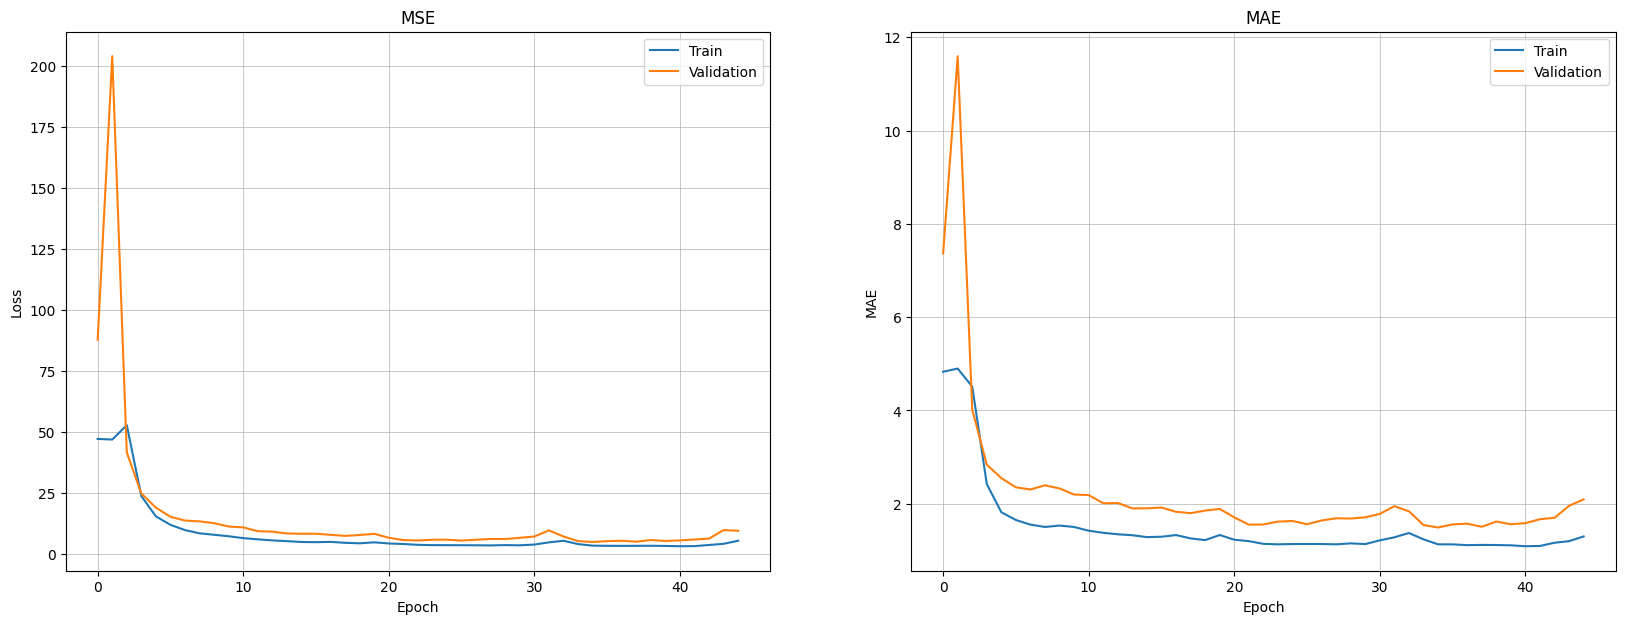

In [ ]:
plot_history(history);


In [ ]:
# 3 - Evaluation
# ====================================
res = model.evaluate(X_test, y_test)
print(f"The LSTM MAE on the test set is equal to {round(res[1],2)} Celsius degrees")


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.2520 - mae: 1.6009
The LSTM MAE on the test set is equal to 1.51 Celsius degrees


## (2.2) 💻 LSTM'imizle Karşılaştıracağımız Bir Temel Model!

👉 Zaman Serilerinde, "sezgisel" bir temel model, tahmin etmek istediğiniz gelecek değer(ler) için **son görülen değeri** tahmin etmektir, aşağıda gösterildiği gibi!

<img src = "https://github.com/lewagon/data-images/blob/master/DL/rnn_time_series_no_horizon.png?raw=true" width = 600, height = 300>

💻 ❓ **Soru (Son Görülen Değer Temel Modeli)** ❓ 

LSTM'ye benzer şekilde bir temel model başlatan ve derleyen yeni bir `init_baseline` metodu oluşturun.

- Temel model bir [📚 Keras Lambda Katmanı](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Lambda) olmalıdır
- 0 eğitilebilir parametresi olduğundan dolayı bir `fit`'e bile ihtiyacı olmamalıdır
- Sonra, bu FOLD için MAE'yi hesaplayın ve LSTM'yi eğittikten sonra test seti üzerinde elde ettiğiniz MAE ile karşılaştırın
 
<details>
    <summary markdown='span'>💡 <i>İpucu</i></summary>

- `X_train[:,:,1]`'in sıcaklık zaman seriniz olduğunu unutmayın (`fold`'unuzdaki ikinci sütundur) 
</details>


In [ ]:
from keras.layers import Lambda

def init_baseline():

    # $CHALLENGIFY_BEGIN
    model = models.Sequential()
    model.add(layers.Lambda(lambda x: x[:,-1,1,None]))

    adam = optimizers.Adam(learning_rate=0.02)
    model.compile(loss='mse', optimizer=adam, metrics=["mae"])

    return model
    # $CHALLENGIFY_END


In [ ]:
baseline_model = init_baseline()
baseline_score = baseline_model.evaluate(X_test, y_test)
print(f"- The Baseline MAE on the test set is equal to {round(baseline_score[1],2)} Celsius degrees")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - loss: 6.6628 - mae: 1.8652
- The Baseline MAE on the test set is equal to 2.06 Celsius degrees


In [ ]:
print(f"- The LSTM MAE on the test set is equal to {round(res[1],2)} Celsius degrees")
print(f"🔥 Improvement of the LSTM model over the baseline (on this fold for the test set) = : {round((1 - (res[1]/baseline_score[1]))*100,2)} % 🔥")


- The LSTM MAE on the test set is equal to 1.51 Celsius degrees
🔥 Improvement of the LSTM model over the baseline (on this fold for the test set) = : 27.01 % 🔥


## (2.3) 💻 Çapraz Doğrulama

**"Büyük resmi"** hatırlıyor musunuz? 

<br>

<details>
    <summary markdown='span'><i>Büyük resim</i></summary>


<b><u>Adım 1: Zaman Serilerinde Çapraz Doğrulama [FOLD'lar] </u></b>

* Bu tek Zaman Serisi'nden başlayarak, <font color="#c91ac9">**FOLD'lar**</font> oluşturacağız...
* ... ve sinir ağının sağlamlığı hakkında sonuç çıkarmak için LSTM'imizi bu farklı <font color="#c91ac9">**FOLD'lar**</font> üzerinde eğitip/değerlendireceğiz
* Tüm dış koşul türlerini kapsayacak şekilde Zaman Serisi tahminlemede ***yüzlerce*** <font color="#c91ac9">**FOLD**</font> oluşturmak çok yaygındır: örn.
    - çöküş piyasa dönemleri 📉
    - boğa piyasalar 📈
    - durgun piyasalar 😴, vb...

<b><u>Adım 2: Her fold içinde Holdout yöntemi [EĞİTİM-TEST AYRIMI]</u></b>

* Her <font color="#c91ac9">**FOLD**</font> için, bir EĞİTİM-TEST AYRIMI yapacağız:
    * Modeli <font color=blue>**eğitim**</font> seti üzerinde <font color=blue>**fit**</font> etmek 
    * ve <font color="#ff8005">**test**</font> seti üzerinde <font color="#ff8005">**değerlendirmek**</font>
    * Eğitim setini her zaman test setinden **kronolojik olarak** önce bölün!

👇 İlk iki adım, 4 FOLD içeren aşağıdaki görüntüde özetlenebilir:

<img src="https://bit.ly/3yLoa92" alt="Time Series Cross Validation" width="500" height="500">


<b><u>Adım 3: Hem eğitim seti hem de test setinde SEKANSLAR örnekleme</u></b>

Her <font color=blue>**eğitim**</font> setinde ve her <font color="#ff8005">**test**</font> setinde, aşağıda gösterildiği gibi <font color=magenta>**rastgele sekanslar**</font> oluşturacağız 👇:

<img src="https://bit.ly/3Ri8Vfd" alt="Sequences in each fold" width="500" height="500"> 


</details>

❗️ ***Uyarılar*** ❗️

* <u><i>adım 2</i></u>'yi (<font color="blue">eğitim</font>/<font color="orange">test</font> ayrımı) ve <u><i>adım 3</i></u>'yi (get_X_y) yalnızca **<font color="#c91ac9">tek bir FOLD için</font>** yaptığımızı aklda tutun. 
* ***Bir modelin sağlamlığını sağlamak istiyorsak, modeli <font color="#c91ac9">TÜM fold'lar</font> üzerinde çapraz doğrulamamız gerekir!***


In [ ]:
# Reminders of the global variables in this notebook

print(f'N_FEATURES = {N_FEATURES}')
print(f'N_TARGETS = {N_TARGETS}')
print('')
print(f'FOLD_LENGTH = {FOLD_LENGTH}')
print(f'FOLD_STRIDE = {FOLD_STRIDE}')
print(f'TRAIN_TEST_RATIO = {TRAIN_TEST_RATIO}')
print('')
print(f'N_TRAIN = {N_TRAIN}')
print(f'N_TEST = {N_TEST}')
print(f'INPUT_LENGTH = {INPUT_LENGTH}')
print(f'OUTPUT_LENGTH = {OUTPUT_LENGTH}')


N_FEATURES = 19
N_TARGETS = 1

FOLD_LENGTH = 8760
FOLD_STRIDE = 728
TRAIN_TEST_RATIO = 0.66

N_TRAIN = 6666
N_TEST = 3333
INPUT_LENGTH = 112
OUTPUT_LENGTH = 1


In [ ]:
# Remember how many folds do we have ?
folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)

print(f"WARNING, we have {len(folds)} FOLDS, so you may want to run the cross-validation of the RNN on Colab.")


WARNING, we have 21 FOLDS, so you may want to run the cross-validation of the RNN on Colab.


💻 **❓ Temel çizginizi ve modelinizi bir for döngüsünde çapraz doğrulayın!❓**

Daha önce tanımladığınız metotları yeniden kullanarak
- `get_folds`
- `train_test_split`
- `get_X_y`
- `init_model`
- `init_baseline`

In [ ]:
from keras.callbacks import EarlyStopping

def cross_validate_baseline_and_lstm():
    '''
    This function cross-validates
    - the "last seen value" baseline model
    - the RNN model
    '''

    list_of_mae_baseline_model = []
    list_of_mae_recurrent_model = []

    # 0 - Creating folds
    # =========================================
    folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)

    for fold_id, fold in enumerate(folds):

        # 1 - Train/Test split the current fold
        # =========================================
        (fold_train, fold_test) = train_test_split(fold, TRAIN_TEST_RATIO, INPUT_LENGTH)

        X_train, y_train = get_X_y(fold_train, N_TRAIN, INPUT_LENGTH, OUTPUT_LENGTH)
        X_test, y_test = get_X_y(fold_test, N_TEST, INPUT_LENGTH, OUTPUT_LENGTH)

        # 2 - Modelling
        # =========================================

        ##### Baseline Model
        baseline_model = init_baseline()
        mae_baseline = baseline_model.evaluate(X_test, y_test, verbose=0)[1]
        list_of_mae_baseline_model.append(mae_baseline)
        print("-"*50)
        print(f"MAE baseline fold n°{fold_id} = {round(mae_baseline, 2)}")

        ##### LSTM Model
        model = init_model(X_train, y_train)
        es = EarlyStopping(monitor = "val_mae",
                           mode = "min",
                           patience = 2,
                           restore_best_weights = True)
        history = model.fit(X_train, y_train,
                            validation_split = 0.3,
                            shuffle = False,
                            batch_size = 32,
                            epochs = 50,
                            callbacks = [es],
                            verbose = 0)
        res = model.evaluate(X_test, y_test, verbose=0)
        mae_lstm = res[1]
        list_of_mae_recurrent_model.append(mae_lstm)
        print(f"MAE LSTM fold n°{fold_id} = {round(mae_lstm, 2)}")

        ##### Comparison LSTM vs Baseline for the current fold
        print(f"🏋🏽‍♂️ improvement over baseline: {round((1 - (mae_lstm/mae_baseline))*100,2)} % \n")

    return list_of_mae_baseline_model, list_of_mae_recurrent_model


In [ ]:
%%time
# WARNING : it takes 15 minutes to run this cell (MacBook Air M1)
mae_baselines, mae_lstms = cross_validate_baseline_and_lstm()


--------------------------------------------------
MAE baseline fold n°0 = 2.04
MAE LSTM fold n°0 = 1.2
🏋🏽‍♂️ improvement over baseline: 41.11 % 

--------------------------------------------------
MAE baseline fold n°1 = 2.04
MAE LSTM fold n°1 = 1.31
🏋🏽‍♂️ improvement over baseline: 35.85 % 

--------------------------------------------------
MAE baseline fold n°2 = 1.92
MAE LSTM fold n°2 = 1.24
🏋🏽‍♂️ improvement over baseline: 35.44 % 

--------------------------------------------------
MAE baseline fold n°3 = 2.02
MAE LSTM fold n°3 = 1.19
🏋🏽‍♂️ improvement over baseline: 41.15 % 

--------------------------------------------------
MAE baseline fold n°4 = 1.87
MAE LSTM fold n°4 = 1.24
🏋🏽‍♂️ improvement over baseline: 33.5 % 

--------------------------------------------------
MAE baseline fold n°5 = 1.74
MAE LSTM fold n°5 = 1.04
🏋🏽‍♂️ improvement over baseline: 40.34 % 

--------------------------------------------------
MAE baseline fold n°6 = 1.65
MAE LSTM fold n°6 = 1.03
🏋🏽‍♂️ imp

In [ ]:
print(f"average percentage improvement over baseline = {round(np.mean(1 - (np.array(mae_lstms)/np.array(mae_baselines))),2)*100}%")


average percentage improvement over baseline = 37.0%


## Teşekkürler

* Bu challenge gerçekten `Google>Tensorflow>Keras`'tan `Zaman Serisi Tahmini` eğitiminden ilham aldı
* Teknik fonksiyonlar Bruno Lajoie'nin [Zaman Serileri hakkındaki data-template paketi](https://github.com/lewagon/data-templates/tree/main/project-boilerplates)nden ilham aldı

# (Bonus) Orijinal veri seti 

🥋 Özellik mühendisliği becerilerinizi pratik etmek istiyorsanız, daha sonra bu challenge'a geri dönün, orijinal veri setini indirin ve üzerinde çalışın.

In [ ]:
#########################################################
# Uncomment later -not today- to download the original  #
# dataset and try to perform the features engineering   #
# by yourself                                           #
#########################################################


zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)

raw = pd.read_csv(csv_path)

print(f"raw.shape = {raw.shape}")
display(raw.head())


raw.shape = (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
# Inspecting each feature to detect their type and null values
raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  object 
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


In [ ]:
# Slice [start:stop:step],
# starting from index 5, take every 6th record
# to get only hourly records

# $CHALLENGIFY_BEGIN
df = raw[5::6].copy()
df.head()
# $CHALLENGIFY_END


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,01.01.2009 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,01.01.2009 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,01.01.2009 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,01.01.2009 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


In [ ]:
# Convert the "Date Time" column to a datetime format

# $CHALLENGIFY_BEGIN
df["Date Time"] = pd.to_datetime(df["Date Time"])
# $CHALLENGIFY_END


In [ ]:
# Describe the dataset

# $CHALLENGIFY_BEGIN
round(df.describe().transpose(),2)
# $CHALLENGIFY_END


,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.21,8.36,913.60,984.20,989.57,994.72,1015.29
T (degC),70091.0,9.45,8.42,-22.76,3.35,9.41,15.48,37.28
Tpot (K),70091.0,283.49,8.50,250.85,277.44,283.46,289.53,311.21
Tdew (degC),70091.0,4.96,6.73,-24.80,0.24,5.21,10.08,23.06
rh (%),70091.0,76.01,16.47,13.88,65.21,79.30,89.40,100.00
VPmax (mbar),70091.0,13.58,7.74,0.97,7.77,11.82,17.61,63.77
VPact (mbar),70091.0,9.53,4.18,0.81,6.22,8.86,12.36,28.25
VPdef (mbar),70091.0,4.04,4.90,0.00,0.87,2.19,5.30,46.01
sh (g/kg),70091.0,6.02,2.66,0.51,3.92,5.59,7.80,18.07
H2OC (mmol/mol),70091.0,9.64,4.23,0.81,6.29,8.96,12.49,28.74


In [ ]:
## Fixing the wv, look at the absurd values and replace them with zero

# $CHALLENGIFY_BEGIN
wv = df['wv (m/s)']
bad_wv = (wv == -9999.0)
df.loc[bad_wv, 'wv (m/s)'] = 0.0
# $CHALLENGIFY_END

## Fixing the max wv

# $CHALLENGIFY_BEGIN
max_wv = df['max. wv (m/s)']
bad_max_wv = max_wv == -9999.0
df.loc[bad_max_wv, 'max. wv (m/s)'] = 0.0
# $CHALLENGIFY_END


--------------------------------------------------
Working with angles...


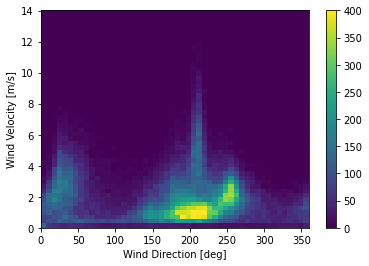

--------------------------------------------------
Working with wind vectors


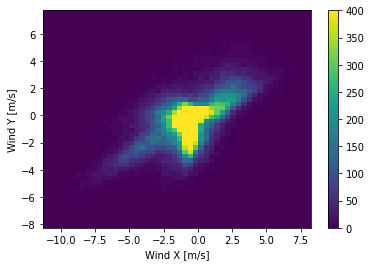

In [ ]:
# Wind : Wd degrees from 0 to 360 egrees
# Angles do not make good models inputs because 0 and 360 should be "close"

print('-'*50)
print("Working with angles...")

plt.hist2d(df['wd (deg)'], df['wv (m/s)'],
           bins=(50, 50),
           vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')
plt.show()

# It is much easier for the model to interpret
# the wind direction and the wind velocity through a vector


# Convert degrees to radians and store the values into wd_rad
# $CHALLENGIFY_BEGIN
wd_rad = df.pop('wd (deg)') * np.pi / 180
# $CHALLENGIFY_END

# Calculate the wind x and y components and store them in two new columns
# `Wx` and `Wy`
# $CHALLENGIFY_BEGIN
wv = df.pop('wv (m/s)')
df['Wx'] = - wv * np.cos(wd_rad)
df['Wy'] = - wv * np.sin(wd_rad)
# Using minus because Wd is the direction of the wind's ORIGIN
# $CHALLENGIFY_END

# Calculate the max wind x and y components and store them in two new columns
# `max Wx` and `max Wy`
# $CHALLENGIFY_BEGIN
max_wv = df.pop('max. wv (m/s)')
df['max Wx'] = - max_wv * np.cos(wd_rad)
df['max Wy'] = - max_wv * np.sin(wd_rad)
# $CHALLENGIFY_END

print('-'*50)
print("Working with wind vectors")

plt.hist2d(df['Wx'], df['Wy'],
           bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')
plt.show()

# $CHALLENGIFY_END


In [ ]:
# Similarly to the wind direction, the time in seconds is not a useful model input
# The weather dataset has clear daily and yearly periodicities
# Using sine and cosine functions, we can compute:
# - the time of the day
# - the time of the year

# $CHALLENGIFY_BEGIN

# Collecting the timestamps
datetime_df = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')
timestamps_s = datetime_df.map(pd.Timestamp.timestamp)
timestamps_s

# 24 hours x 60 minutes/hour x 60 seconds/minute
day = 24*60*60
# 1 year in days
year = (365.2425)*day

# Day periodicity
df['Day_sin'] = np.sin(timestamps_s * (2 * np.pi / day))
df['Day_cos'] = np.cos(timestamps_s * (2 * np.pi / day))

# Year periodicity
df['Year_sin'] = np.sin(timestamps_s * (2 * np.pi / year))
df['Year_cos'] = np.cos(timestamps_s * (2 * np.pi / year))

# $CHALLENGIFY_END


In [ ]:
# Select every 3 hours

# $CHALLENGIFY_BEGIN
df = df[2::3].reset_index(drop = True)
df
# $CHALLENGIFY_END


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy,Day_sin,Day_cos,Year_sin,Year_cos
0,996.84,-8.81,264.59,-9.66,93.50,3.13,2.93,0.20,1.83,2.94,1312.18,-0.175527,0.039879,-0.614344,0.139576,7.071068e-01,7.071068e-01,0.011483,0.999934
1,997.71,-9.67,263.66,-10.62,92.70,2.93,2.71,0.21,1.69,2.72,1317.71,-0.041452,0.027960,-0.414519,0.279596,1.000000e+00,4.339955e-12,0.013633,0.999907
2,999.69,-7.66,265.52,-8.84,91.20,3.43,3.13,0.30,1.95,3.13,1310.14,-0.314796,-0.128466,-0.583298,-0.238040,7.071068e-01,-7.071068e-01,0.015783,0.999875
3,1000.30,-6.87,266.27,-8.28,89.60,3.64,3.27,0.38,2.03,3.26,1306.98,-1.834577,-0.141163,-2.622249,-0.201771,6.903299e-12,-1.000000e+00,0.017933,0.999839
4,999.88,-5.69,267.48,-7.00,90.40,3.99,3.61,0.38,2.25,3.61,1300.51,-0.825870,0.828758,-1.327039,1.331679,-7.071068e-01,-7.071068e-01,0.020083,0.999798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23358,1006.23,-6.31,266.37,-8.42,84.90,3.81,3.23,0.57,2.00,3.21,1312.01,-1.279930,-0.013404,-1.839899,-0.019268,6.755902e-01,-7.372773e-01,-0.000268,1.000000
23359,1004.62,-0.71,272.09,-5.97,67.37,5.80,3.91,1.89,2.42,3.89,1282.65,-0.976457,-0.412471,-1.916066,-0.809378,-4.361939e-02,-9.990482e-01,0.001883,0.999998
23360,1003.09,4.97,277.88,-3.04,56.03,8.71,4.88,3.83,3.03,4.86,1254.09,-0.403185,-0.359224,-0.776504,-0.691840,-7.372773e-01,-6.755902e-01,0.004033,0.999992
23361,1002.27,-0.42,272.56,-4.92,71.50,5.92,4.23,1.69,2.63,4.22,1278.14,-0.266024,-0.350473,-0.604599,-0.796530,-9.990482e-01,4.361939e-02,0.006183,0.999981
